### **[Time Series Analysis with DTW and Clustering](https://medium.com/@kyle-t-jones/b8acc709a8d8)**

> *Runnable baselines for elastic-distance classification and shape-based clustering*

In [1]:
# Recommended: Python 3.12+
!pip install --quiet --upgrade tslearn numba

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

from IPython.display import display
from pprint import pprint

from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

from scipy.optimize import linear_sum_assignment

from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesResampler
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.clustering import TimeSeriesKMeans, KShape

import warnings
warnings.filterwarnings('ignore')

RNG = np.random.default_rng(7)

In [3]:
def make_wave(kind='sine', length=120, noise=0.05, warp=1.0):
    t = np.linspace(0, 1, int(length * warp), endpoint=True)
    if kind == 'sine':
        x = np.sin(2*np.pi*t)
    elif kind == 'square':
        x = np.sign(np.sin(2*np.pi*t))
    elif kind == 'bump':
        x = np.exp(-((t-0.5)**2)/(2*0.06**2)) * 2 - 1
    else:
        raise ValueError(kind)
    x = x + RNG.normal(0, noise, size=x.size)
    # z-score per sequence
    x = (x - x.mean()) / (x.std() + 1e-6)
    return x

classes = ['sine','square','bump']
N_SUBJ = 24
N_PER = 15
X_list, y, groups = [], [], []
for subj in range(N_SUBJ):
    base = RNG.choice(classes)
    for _ in range(N_PER):
        kind = base if RNG.random() < 0.7 else RNG.choice(classes)
        L = int(RNG.integers(90, 160))
        warp = float(RNG.uniform(0.8, 1.25))
        X_list.append(make_wave(kind, length=L, noise=0.08, warp=warp))
        y.append(classes.index(kind))
        groups.append(subj)
y = np.array(y)
groups = np.array(groups)

print(f"X_list: {len(X_list)}")
print(f"y shape: {y.shape}")
print(f"Groups shape: {groups.shape}")

X_list: 360
y shape: (360,)
Groups shape: (360,)


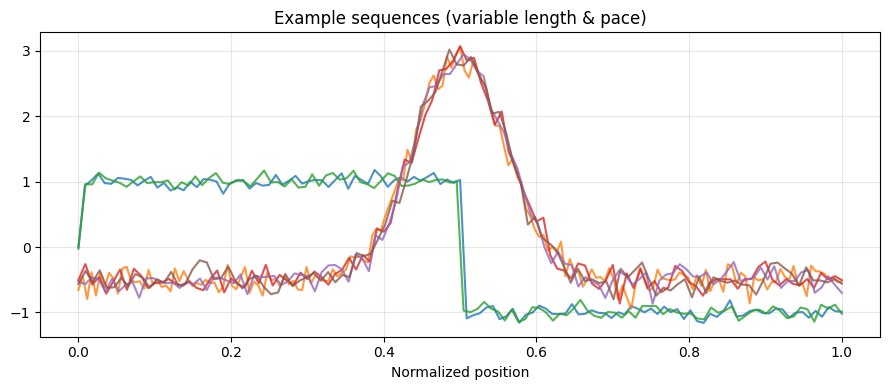

In [4]:
plt.figure(figsize=(9,4))
for k in range(6):
    s = X_list[k]
    plt.plot(np.linspace(0,1,len(s)), s, alpha=0.8, label=f"y={y[k]}")
plt.title('Example sequences (variable length & pace)')
plt.xlabel('Normalized position')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
TARGET_LEN = 128
resampler = TimeSeriesResampler(sz=TARGET_LEN)
# Build 3D array with one feature
X_fixed = np.array([np.interp(np.linspace(0,1,TARGET_LEN), np.linspace(0,1,len(x)), x) for x in X_list])
X_fixed = X_fixed[:, :, None]

cv = GroupKFold(n_splits=5)
results = []

for metric in ["dtw", "softdtw"]:
    f1s = []
    cms = np.zeros((3,3), dtype=int)
    clf = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric=metric)
    for tr, te in cv.split(X_fixed, y, groups):
        clf.fit(X_fixed[tr], y[tr])
        pred = clf.predict(X_fixed[te])
        rep = classification_report(y[te], pred, output_dict=True)
        f1s.append(rep['weighted avg']['f1-score'])
        cms += confusion_matrix(y[te], pred, labels=[0,1,2])
    results.append({
        'metric': metric,
        'f1_weighted': float(np.mean(f1s)),
        'f1_std': float(np.std(f1s)),
        'confusion': cms
    })
pprint(results)

[{'confusion': array([[150,   0,   0],
       [  0, 120,   0],
       [  0,   0,  90]]),
  'f1_std': 0.0,
  'f1_weighted': 1.0,
  'metric': 'dtw'},
 {'confusion': array([[150,   0,   0],
       [  0, 120,   0],
       [  0,   0,  90]]),
  'f1_std': 0.0,
  'f1_weighted': 1.0,
  'metric': 'softdtw'}]


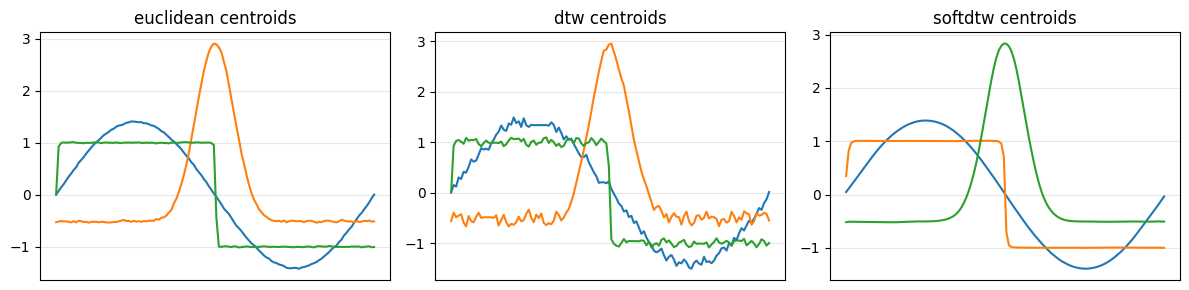

In [6]:
n_clusters = 3
models = {
    'euclidean': TimeSeriesKMeans(n_clusters=n_clusters, metric='euclidean', random_state=0),
    'dtw': TimeSeriesKMeans(n_clusters=n_clusters, metric='dtw', max_iter=10, random_state=0),
    'softdtw': TimeSeriesKMeans(n_clusters=n_clusters, metric='softdtw', max_iter=10, random_state=0)
}

fits = {name: mdl.fit(X_fixed) for name, mdl in models.items()}
centroids = {name: mdl.cluster_centers_.squeeze(-1) for name, mdl in fits.items()}
plt.figure(figsize=(12,3))
for i, (name, C) in enumerate(centroids.items()):
    plt.subplot(1,3,i+1)
    for k in range(n_clusters):
        plt.plot(C[k], label=f'C{k}')
    plt.title(f'{name} centroids')
    plt.xticks([])
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

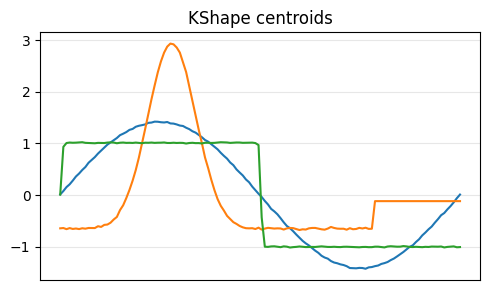

In [7]:
kshape = KShape(n_clusters=3, random_state=0)
ks_fit = kshape.fit(X_fixed)
ks_cent = ks_fit.cluster_centers_.squeeze(-1)

plt.figure(figsize=(5,3))
for k in range(3):
    plt.plot(ks_cent[k], label=f'K{k}')
plt.title('KShape centroids')
plt.xticks([])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
assign = fits['dtw'].labels_
K = 3
cost = np.zeros((K, K), dtype=int)
for k in range(K):
    for c in range(K):
        cost[k, c] = np.sum((assign == k) & (y == c))
# Maximize total count: minimize negative count
row_ind, col_ind = linear_sum_assignment(cost.max() - cost)
acc = cost[row_ind, col_ind].sum() / len(y)
pprint(acc)

np.float64(1.0)


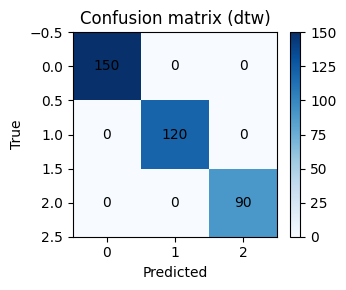

In [9]:
best = max(results, key=lambda d: d['f1_weighted'])
cm = best['confusion']
fig, ax = plt.subplots(figsize=(4,3))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f"Confusion matrix ({best['metric']})")
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center', color='black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [10]:
from tslearn.datasets import UCR_UEA_datasets

try:
    ucr = UCR_UEA_datasets(use_cache=True)
    X_tr, y_tr, X_te, y_te = ucr.load_dataset("ECG200")
    if X_tr is not None:
        # z-score each series (UCR data is not always normalized)
        for arr in [X_tr, X_te]:
            arr -= arr.mean(axis=1, keepdims=True)
            arr /= (arr.std(axis=1, keepdims=True) + 1e-6)
        knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric='dtw')
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_te)
        print(classification_report(y_te, y_pred))
    else:
        raise RuntimeError("load_dataset returned None")
except Exception as e:
    print("UCR loader failed, use synthetic data from above:", e)

              precision    recall  f1-score   support

          -1       0.69      0.67      0.68        36
           1       0.82      0.83      0.82        64

    accuracy                           0.77       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.77      0.77      0.77       100



In [11]:
# Classifier with constrained DTW
band = 10  # radius in time steps (on resampled length)
knn_sc = KNeighborsTimeSeriesClassifier(
    n_neighbors=1,
    metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': band}
)

cv = GroupKFold(n_splits=5)
f1s_sc = []
for tr, te in cv.split(X_fixed, y, groups):
    knn_sc.fit(X_fixed[tr], y[tr])
    pred = knn_sc.predict(X_fixed[te])
    f1s_sc.append(classification_report(y[te], pred, output_dict=True)['weighted avg']['f1-score'])
print('Constrained-DTW KNN weighted F1:', float(np.mean(f1s_sc)))
# KMeans with constrained DTW
km_sc = TimeSeriesKMeans(n_clusters=3, metric='dtw',
                         metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': band},
                         random_state=0, max_iter=10)
km_sc_fit = km_sc.fit(X_fixed)

Constrained-DTW KNN weighted F1: 1.0


In [12]:
try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader

    Xc = (X_fixed.squeeze(-1) - X_fixed.squeeze(-1).mean(axis=1, keepdims=True)) / (X_fixed.squeeze(-1).std(axis=1, keepdims=True) + 1e-6)
    Xc = Xc[:, None, :]  # (N, C=1, L)
    class CNN1D(nn.Module):
        def __init__(self, n_classes=3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(1, 16, 7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
                nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
            )
            self.fc = nn.Linear(32, n_classes)
        def forward(self, x):
            x = self.net(x).squeeze(-1)
            return self.fc(x)
    cv = GroupKFold(n_splits=5)
    f1s = []
    for tr, te in cv.split(Xc, y, groups):
        model = CNN1D(n_classes=3)
        opt = optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.CrossEntropyLoss()
        ds_tr = TensorDataset(torch.tensor(Xc[tr], dtype=torch.float32), torch.tensor(y[tr], dtype=torch.long))
        dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
        model.train()
        for epoch in range(3):  # minimal training: sanity check, not full fit
            for xb, yb in dl_tr:
                opt.zero_grad(); logits = model(xb); loss = loss_fn(logits, yb); loss.backward(); opt.step()
        with torch.no_grad():
            logits = model(torch.tensor(Xc[te], dtype=torch.float32))
            pred = logits.argmax(dim=1).cpu().numpy()
        f1s.append(classification_report(y[te], pred, output_dict=True)['weighted avg']['f1-score'])
    print('CNN1D weighted F1:', float(np.mean(f1s)))
except Exception as e:
    print('Skipping CNN demo (PyTorch unavailable or error):', e)

CNN1D weighted F1: 0.2597282616236127
